In [2]:
# %%
# VBZ passenger flows in Zürich – from raw OGD to georeferenced flows

# This notebook:
# 1. Loads the VBZ Fahrgastzahlen (passenger counts) and matching tables from Open Data Zürich
# 2. Aggregates an "average weekday" (Werktag) network: passenger volumes per segment & hour
# 3. Uses ZVV GTFS (static) to approximate geometries for stops
# 4. Builds georeferenced flows (LineString per segment) and plots them on a map of Zürich

# ---
# Requirements (install in your environment if needed):
# !pip install pandas geopandas shapely requests contextily pyproj

import io
import zipfile
import requests

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import contextily as ctx


In [3]:
# %%
# 1. Load VBZ passenger data directly from Open Data Zürich

BASE_VBZ_URL = "https://data.stadt-zuerich.ch/dataset/vbz_fahrgastzahlen_ogd/download/"

URL_REISENDE = BASE_VBZ_URL + "REISENDE.csv"
URL_TAGTYP = BASE_VBZ_URL + "TAGTYP.csv"
URL_HALTESTELLEN = BASE_VBZ_URL + "HALTESTELLEN.csv"
URL_LINIE = BASE_VBZ_URL + "LINIE.csv"

print("Downloading REISENDE.csv (this is the main ~70MB table, may take a bit)...")
reisende_raw = pd.read_csv(URL_REISENDE,sep=";")

print("Downloading TAGTYP.csv...")
tagtyp = pd.read_csv(URL_TAGTYP, sep=";")

print("Downloading HALTESTELLEN.csv...")
haltestellen = pd.read_csv(URL_HALTESTELLEN, sep=";")

print("Downloading LINIE.csv...")
linie = pd.read_csv(URL_LINIE, sep=";")

reisende_raw.head(), tagtyp.head(), haltestellen.head(), linie.head()


(   Tagtyp_Id  Linien_Id  Linienname  Plan_Fahrt_Id  Richtung  Sequenz  \
 0          4         35           2          35927         1        6   
 1          4         35           2          35927         1        7   
 2          4         35           2          35927         1        8   
 3          4         35           2          35927         1        9   
 4          4         35           2          35927         1       10   
 
    Haltestellen_Id  Nach_Hst_Id     FZ_AB  Anzahl_Messungen  ...  Besetzung  \
 0              297        258.0  17:32:30                62  ...   59.29032   
 1              258        428.0  17:33:36                62  ...   66.32258   
 2              428        154.0  17:34:48                62  ...   71.35484   
 3              154        427.0  17:35:54                62  ...   85.59677   
 4              427        103.0  17:37:06                62  ...   94.64516   
 
    Distanz  Tage_DTV  Tage_DWV  Tage_SA  Tage_SO  Nachtnetz  Tage_SA_N 

In [4]:
reisende_raw.Nach_Hst_Id

0         258.0
1         428.0
2         154.0
3         427.0
4         103.0
          ...  
793706    137.0
793707      NaN
793708    286.0
793709    264.0
793710    243.0
Name: Nach_Hst_Id, Length: 793711, dtype: float64

In [5]:
# %%
# 2. Basic cleaning and typing

reisende = reisende_raw.copy()

# Numeric columns in REISENDE come in as text; convert to numeric
numeric_cols = [
    "Einsteiger", "Aussteiger", "Besetzung", "Distanz",
    "Tage_DTV", "Tage_DWV", "Tage_SA", "Tage_SO",
    "Tage_SA_N", "Tage_SO_N"
]
for col in numeric_cols:
    if col in reisende.columns:
        reisende[col] = pd.to_numeric(reisende[col], errors="coerce")

# Convert Nach_Hst_Id to integer
reisende.Nach_Hst_Id = reisende.Nach_Hst_Id.astype("Int64")

# Parse departure time FZ_AB -> hour of day
# FZ_AB is hh:mm (no date); we only need the hour
reisende["hour"] = pd.to_datetime(reisende["FZ_AB"], format="%H:%M:%S", errors="coerce").dt.hour
reisende["hour"].fillna(-1, inplace=True)  # -1 = unknown / failed parse

reisende.head()
reisende.Haltestellen_Id.head(), reisende.Tagtyp_Id.head(), reisende.Nach_Hst_Id.head(), reisende.Linien_Id.head()


/var/folders/dz/xk92rf811x11gfspml0l9cdr0000gn/T/ipykernel_12689/4045927258.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reisende["hour"].fillna(-1, inplace=True)  # -1 = unknown / failed parse


(0    297
 1    258
 2    428
 3    154
 4    427
 Name: Haltestellen_Id, dtype: int64,
 0    4
 1    4
 2    4
 3    4
 4    4
 Name: Tagtyp_Id, dtype: int64,
 0    258
 1    428
 2    154
 3    427
 4    103
 Name: Nach_Hst_Id, dtype: Int64,
 0    35
 1    35
 2    35
 3    35
 4    35
 Name: Linien_Id, dtype: int64)

In [6]:
# %%
# 3. Join TAGTYP to identify weekday (Werktag) records
tagtyp.Tagtyp_Id = tagtyp.Tagtyp_Id.astype("int64")


#tagtyp["Tagtyp_Id"] = tagtyp["Tagtyp_Id"].astype(str)
reisende = reisende.merge(tagtyp[["Tagtyp_Id", "Tagtypname", "Bemerkung"]],
                          on="Tagtyp_Id", how="left")

# Here could subset to tagtyp, now keeping everything
#weekday_ids = []
#reisende_weekday = reisende[reisende["Tagtyp_Id"].isin(weekday_ids)].copy()

reisende_weekday = reisende.copy()


In [7]:
reisende_weekday.head()

,Tagtyp_Id,Linien_Id,Linienname,Plan_Fahrt_Id,Richtung,Sequenz,Haltestellen_Id,Nach_Hst_Id,FZ_AB,Anzahl_Messungen,...,Tage_DWV,Tage_SA,Tage_SO,Nachtnetz,Tage_SA_N,Tage_SO_N,ID_Abschnitt,hour,Tagtypname,Bemerkung
0,4,35,2,35927,1,6,297,258,17:32:30,62,...,251.0,0.0,0.0,0,0.0,0.0,29700258,17.0,15-A1-24,Jahresfahrplan Montag-Freitag
1,4,35,2,35927,1,7,258,428,17:33:36,62,...,251.0,0.0,0.0,0,0.0,0.0,25800428,17.0,15-A1-24,Jahresfahrplan Montag-Freitag
2,4,35,2,35927,1,8,428,154,17:34:48,62,...,251.0,0.0,0.0,0,0.0,0.0,42800154,17.0,15-A1-24,Jahresfahrplan Montag-Freitag
3,4,35,2,35927,1,9,154,427,17:35:54,62,...,251.0,0.0,0.0,0,0.0,0.0,15400427,17.0,15-A1-24,Jahresfahrplan Montag-Freitag
4,4,35,2,35927,1,10,427,103,17:37:06,62,...,251.0,0.0,0.0,0,0.0,0.0,42700103,17.0,15-A1-24,Jahresfahrplan Montag-Freitag


In [8]:
# %%
# 4. Build a flow dataset: passenger volume per segment and hour
#
# Each REISENDE row corresponds to one timetable run between Haltestellen_Id and Nach_Hst_Id
# with an average occupancy "Besetzung" for that segment.
#
# We'll approximate "flow" as the sum of Besetzung over all runs for a given hour of day
# on a typical weekday, aggregated per segment (Haltestellen_Id -> Nach_Hst_Id).

# Drop rows without a next stop (i.e. last stop on a line)
flows = reisende_weekday.dropna(subset=["Nach_Hst_Id"]).copy()

# Only keep rows with a valid hour
flows = flows[flows["hour"] >= 0].copy()

# Aggregate: total Besetzung per segment + hour
segment_hour = (
    flows
    .groupby(["Haltestellen_Id", "Nach_Hst_Id", "hour"], as_index=False)
    .agg(
        flow_besetzung=("Besetzung", "sum"),
        n_runs=("Plan_Fahrt_Id", "nunique")
    )
)

segment_hour.head()
segment_hour.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29310 entries, 0 to 29309
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Haltestellen_Id  29310 non-null  int64  
 1   Nach_Hst_Id      29310 non-null  Int64  
 2   hour             29310 non-null  float64
 3   flow_besetzung   29310 non-null  float64
 4   n_runs           29310 non-null  int64  
dtypes: Int64(1), float64(2), int64(2)
memory usage: 1.1 MB


need to look at id's are mixed up with string conversion

In [1]:
# %%
# 5. Load ZVV GTFS to get approximate stop coordinates
#
# We use the static GTFS feed from Open Data Zürich, e.g. the 2025 feed.
# It contains a stops.txt file with latitude/longitude and stop names.
#
# Note: this is an approximation – stop names may not match 1:1 with VBZ HALTESTELLEN names.
# We align by normalized stop name; unmatched stops will be dropped later.

GTFS_URL = "https://data.stadt-zuerich.ch/dataset/vbz_fahrplandaten_gtfs/download/2025_google_transit.zip"

print("Downloading GTFS 2025 feed (google_transit.zip)...")
resp = requests.get(GTFS_URL)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
    with zf.open("stops.txt") as f:
        gtfs_stops = pd.read_csv(f)

gtfs_stops.head()

NameError: name 'requests' is not defined

In [51]:
# %%
# 6. Normalise stop names and match VBZ HALTESTELLEN to GTFS stops

def normalize_name(s: str) -> str:
    if pd.isna(s):
        return ""
    return (
        s.upper()
        .replace(" (STADT ZÜRICH)", "")  # just in case
        .replace(" (ZÜRICH)", "")
        .strip()
    )

haltestellen["name_norm"] = haltestellen["Haltestellenlangname"].astype(str).map(normalize_name)
gtfs_stops["name_norm"] = gtfs_stops["stop_name"].astype(str).map(normalize_name)

# Many GTFS stops have multiple platforms per stop name; keep mean coordinates per name_norm
gtfs_stops_grouped = (
    gtfs_stops
    .groupby("name_norm", as_index=False)
    .agg(stop_lat=("stop_lat", "mean"), stop_lon=("stop_lon", "mean"))
)

stops_match = haltestellen.merge(gtfs_stops_grouped, on="name_norm", how="left")

print("Match coverage (VBZ HALTESTELLEN with any GTFS coords):")
print(stops_match["stop_lat"].notna().mean())

stops_match.head()

Match coverage (VBZ HALTESTELLEN with any GTFS coords):
0.9075


,Haltestellen_Id,Haltestellennummer,Haltestellenkurzname,Haltestellenlangname,name_norm,stop_lat,stop_lon
0,782,7113,ZHAM,"Zufikon, Hammergut","ZUFIKON, HAMMERGUT",NaN,NaN
1,783,7114,ZSTA,"Zufikon, Station","ZUFIKON, STATION",NaN,NaN
2,44,12543,ZUM,Zumikon,ZUMIKON,47.331960,8.623743
3,433,705,DOZE,"Zumikon, Dorfzentrum","ZUMIKON, DORFZENTRUM",47.333092,8.622689
4,435,1075,GOES,"Zumikon, Gössikon","ZUMIKON, GÖSSIKON",47.332220,8.614462


In [52]:
# %%
# 7. Turn matched stops into a GeoDataFrame

# Keep only stops with coordinates
stops_geo = stops_match.dropna(subset=["stop_lat", "stop_lon"]).copy()

# Create Point geometry in WGS84
stops_geo_gdf = gpd.GeoDataFrame(
    stops_geo,
    geometry=gpd.points_from_xy(stops_geo["stop_lon"], stops_geo["stop_lat"]),
    crs="EPSG:4326"
)

# For plotting with web tiles (contextily) we reproject to Web Mercator
stops_geo_gdf = stops_geo_gdf.to_crs(epsg=3857)

stops_geo_gdf.head()

,Haltestellen_Id,Haltestellennummer,Haltestellenkurzname,Haltestellenlangname,name_norm,stop_lat,stop_lon,geometry
2,44,12543,ZUM,Zumikon,ZUMIKON,47.331960,8.623743,POINT (959990.667 5996427.666)
3,433,705,DOZE,"Zumikon, Dorfzentrum","ZUMIKON, DORFZENTRUM",47.333092,8.622689,POINT (959873.333 5996613.666)
4,435,1075,GOES,"Zumikon, Gössikon","ZUMIKON, GÖSSIKON",47.332220,8.614462,POINT (958957.5 5996470.5)
6,660,3027,FLUG07,"Zürich Flughafen, Bahnhof","ZÜRICH FLUGHAFEN, BAHNHOF",47.450354,8.564011,POINT (953341.334 6015895.666)
7,661,6232,FRAF07,"Zürich Flughafen, Fracht","ZÜRICH FLUGHAFEN, FRACHT",47.452237,8.571530,POINT (954178.4 6016205.6)


In [53]:
# %%
# 8. Download a street network for Zürich from OpenStreetMap using osmnx

# If needed:
# !pip install osmnx networkx

import osmnx as ox
import networkx as nx

# osmnx config: no logging clutter
ox.settings.log_console = False
ox.settings.use_cache = True

# We'll get a graph that covers all stops, using a bounding box
minx, miny, maxx, maxy = stops_geo_gdf.to_crs(epsg=4326).total_bounds  # back to WGS84 for osmnx

# Make a small margin around the bounding box so we don't cut edges right at the stops
margin = 0.01  # ~1 km at this latitude
north = maxy + margin
south = miny - margin
east = maxx + margin
west = minx - margin

print("Downloading street network (driveable roads) from OSM...")
G = ox.graph_from_bbox((west, south, east, north),
    network_type="drive"   # you can also experiment with "drive_service" or "all"
)

# Project graph to a metric CRS (osmnx chooses something like UTM automatically)
G_proj = ox.project_graph(G)
graph_crs = G_proj.graph["crs"]
graph_crs

<Projected CRS: EPSG:32632>
Name: WGS 84 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°E and 12°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Austria. Cameroon. Denmark. Equatorial Guinea. France. Gabon. Germany. Italy. Libya. Liechtenstein. Monaco. Netherlands. Niger. Nigeria. Norway. Sao Tome and Principe. Svalbard. Sweden. Switzerland. Tunisia. Vatican City State.
- bounds: (6.0, 0.0, 12.0, 84.0)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [54]:
# %%
# 9. Project stops into the graph CRS and snap to nearest graph nodes

# Copy stops and project to graph CRS
stops_graph = stops_geo_gdf.to_crs(graph_crs).copy()

# Extract coordinates
xs = stops_graph.geometry.x.values
ys = stops_graph.geometry.y.values

# Find nearest nodes for each stop
print("Finding nearest graph nodes for each stop...")
nearest_nodes = ox.distance.nearest_nodes(G_proj, X=xs, Y=ys)

stops_graph["nearest_node"] = nearest_nodes

# Build lookup: Haltestellen_Id -> nearest_node
stop_node_lookup = (
    stops_graph[["Haltestellen_Id", "nearest_node"]]
    .drop_duplicates(subset="Haltestellen_Id")
    .set_index("Haltestellen_Id")["nearest_node"]
    .to_dict()
)

list(stop_node_lookup.items())[:5]

Finding nearest graph nodes for each stop...


[('44', 240316636),
 ('433', 217282497),
 ('435', 2023767270),
 ('660', 27422125),
 ('661', 92309844)]

In [55]:
# %%
# 10. Compute street-following paths for each stop segment (Haltestellen_Id -> Nach_Hst_Id)

# We assume `segment_hour` exists from before:
# segment_hour columns: ["Haltestellen_Id", "Nach_Hst_Id", "hour", "flow_besetzung", "n_runs"]

# Make sure IDs are strings to match the lookup
segment_hour["Haltestellen_Id"] = segment_hour["Haltestellen_Id"].astype(str)
segment_hour["Nach_Hst_Id"] = segment_hour["Nach_Hst_Id"].astype(str)

# Unique segments (we'll compute one path per (from, to))
unique_segments = (
    segment_hour[["Haltestellen_Id", "Nach_Hst_Id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(len(unique_segments))

unique_segments.head()

1604


,Haltestellen_Id,Nach_Hst_Id
0,4,5
1,4,435
2,5,4
3,5,6
4,6,5


In [56]:
# %%
from shapely.geometry import LineString

# Helper to compute a LineString for a given stop pair
def path_linestring(from_id: str, to_id: str):
    if from_id not in stop_node_lookup or to_id not in stop_node_lookup:
        return None
    
    u = stop_node_lookup[from_id]
    v = stop_node_lookup[to_id]

    try:
        # shortest path by length
        path_nodes = nx.shortest_path(G_proj, u, v, weight="length")
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return None

    # Get coordinates from graph nodes
    coords = [(G_proj.nodes[n]["x"], G_proj.nodes[n]["y"]) for n in path_nodes]

    # If path is degenerate
    if len(coords) < 2:
        return None
    
    return LineString(coords)

# Compute paths for all unique segments
geoms = []
for idx, row in unique_segments.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"Processed {idx} segments...")
    geom = path_linestring(row["Haltestellen_Id"], row["Nach_Hst_Id"])
    geoms.append(geom)

unique_segments["geometry"] = geoms

# Keep only segments with a valid geometry
unique_segments = unique_segments[~unique_segments["geometry"].isna()].copy()

print(f"Segments with valid street-following geometry: {len(unique_segments)}")
unique_segments.head()

Processed 1000 segments...
Segments with valid street-following geometry: 1555


,Haltestellen_Id,Nach_Hst_Id,geometry
0,4,5,LINESTRING (470220.7564958888 5241810.95180508...
1,4,435,LINESTRING (470220.7564958888 5241810.95180508...
2,5,4,LINESTRING (469904.3843340376 5241638.44452178...
3,5,6,LINESTRING (469904.3843340376 5241638.44452178...
4,6,5,"LINESTRING (469637.9285538844 5241555.8162711,..."


In [57]:
# %%
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# 1. Attach street-following geometries to the flow table
flows_geom = segment_hour.merge(
    unique_segments[["Haltestellen_Id", "Nach_Hst_Id", "geometry"]],
    on=["Haltestellen_Id", "Nach_Hst_Id"],
    how="inner"
)

# Make sure it's a GeoDataFrame with the same CRS as the graph
flows_geom = gpd.GeoDataFrame(flows_geom, geometry="geometry", crs=graph_crs)

print(f"Segments with flow + geometry: {len(flows_geom)}")
flows_geom.head()


Segments with flow + geometry: 28468


,Haltestellen_Id,Nach_Hst_Id,hour,flow_besetzung,n_runs,geometry
0,4,5,5.0,4.52963,3,"LINESTRING (470220.756 5241810.952, 470067.843..."
1,4,5,6.0,36.64801,11,"LINESTRING (470220.756 5241810.952, 470067.843..."
2,4,5,7.0,102.42968,14,"LINESTRING (470220.756 5241810.952, 470067.843..."
3,4,5,8.0,46.45516,10,"LINESTRING (470220.756 5241810.952, 470067.843..."
4,4,5,9.0,43.27007,10,"LINESTRING (470220.756 5241810.952, 470067.843..."


In [ ]:
# %%
# 2. Define time slots and aggregate flows per segment & time slot

def time_slot_from_hour(h):
    h = int(h)
    if 7 <= h <= 9:
        return "morning_peak"
    elif 10 <= h <= 15:
        return "midday"
    elif 16 <= h <= 18:
        return "evening_peak"
    elif 19 <= h <= 23:
        return "late"
    else:
        return "off_peak_night"

flows_geom["time_slot"] = flows_geom["hour"].map(time_slot_from_hour)

# Aggregate: total Besetzung per segment & time slot
flows_slot = (
    flows_geom
    .groupby(["Haltestellen_Id", "Nach_Hst_Id", "time_slot"], as_index=False)
    .agg(
        flow_besetzung=("flow_besetzung", "sum"),
        n_runs=("n_runs", "sum"),
        geometry=("geometry", "first")  # geometry per segment is unique
    )
)



flows_slot_gdf = gpd.GeoDataFrame(flows_slot, geometry="geometry", crs=graph_crs)

flows_slot_gdf.head()


,Haltestellen_Id,Nach_Hst_Id,time_slot,flow_besetzung,n_runs,geometry
0,10,11,evening_peak,453.06860,41,"LINESTRING (468467.976 5241139.75, 468455.529 ..."
1,10,11,late,289.02063,53,"LINESTRING (468467.976 5241139.75, 468455.529 ..."
2,10,11,midday,749.97478,60,"LINESTRING (468467.976 5241139.75, 468455.529 ..."
3,10,11,morning_peak,520.68501,35,"LINESTRING (468467.976 5241139.75, 468455.529 ..."
4,10,11,off_peak_night,97.65607,13,"LINESTRING (468467.976 5241139.75, 468455.529 ..."


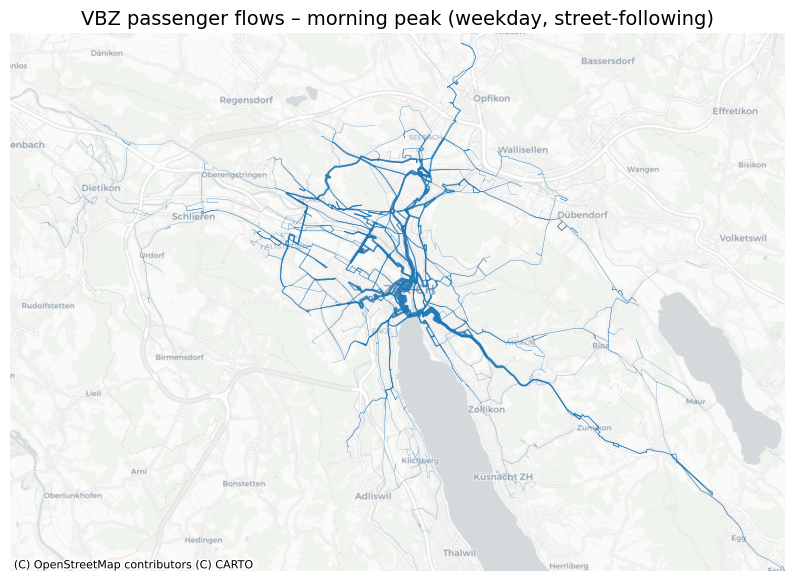

In [60]:
# %%
# 3. Plot morning peak flows through Zürich (street-following)

time_slot_to_plot = "morning_peak"

flows_plot = flows_slot_gdf[flows_slot_gdf["time_slot"] == time_slot_to_plot].copy()

if len(flows_plot) == 0:
    raise ValueError(f"No data for time slot '{time_slot_to_plot}'")

# Reproject to Web Mercator for basemap tiles
flows_plot_web = flows_plot.to_crs(epsg=3857)

# Scale linewidth by intensity (sum of Besetzung)
q90 = flows_plot_web["flow_besetzung"].quantile(0.90)
if q90 <= 0:
    q90 = flows_plot_web["flow_besetzung"].replace(0, pd.NA).dropna().quantile(0.90)

flows_plot_web["weight"] = flows_plot_web["flow_besetzung"] / q90
flows_plot_web["weight"] = flows_plot_web["weight"].clip(lower=0.1, upper=5.0)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot flows
flows_plot_web.plot(
    ax=ax,
    linewidth=flows_plot_web["weight"],
    alpha=0.8
)

# Make sure the extent fits the data
minx, miny, maxx, maxy = flows_plot_web.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()

# Use a provider that definitely exists
# You can also try OpenStreetMap.Mapnik if you prefer
ctx.add_basemap(
    ax,
    crs=flows_plot_web.crs,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("VBZ passenger flows – morning peak (weekday, street-following)", fontsize=14)
plt.show()


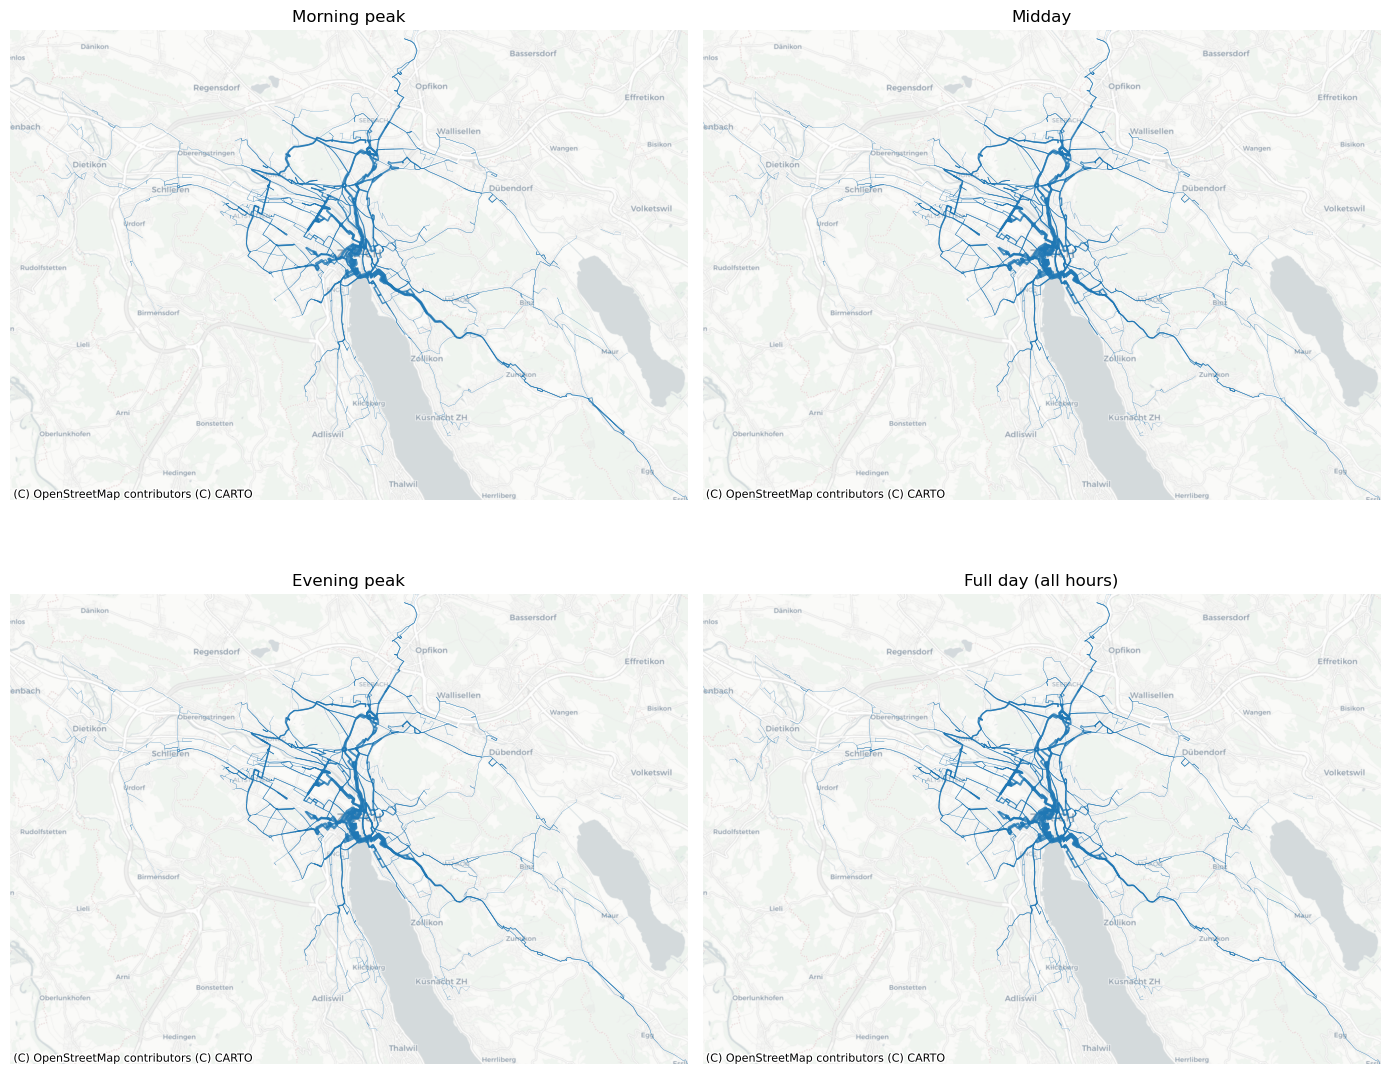

In [62]:
# %%
# Grid of 4 maps: morning, midday, evening, full day

import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
import pandas as pd

# Reproject time-slot flows to Web Mercator for plotting
flows_slot_web = flows_slot_gdf.to_crs(epsg=3857)

# --- Build "full day" aggregation from flows_slot_gdf ---
flows_day = (
    flows_slot_gdf
    .groupby(["Haltestellen_Id", "Nach_Hst_Id"], as_index=False)
    .agg(
        flow_besetzung=("flow_besetzung", "sum"),
        n_runs=("n_runs", "sum"),
        geometry=("geometry", "first")   # geometry is unique per segment
    )
)

# Turn into GeoDataFrame with same CRS as flows_slot_gdf
flows_day_gdf = gpd.GeoDataFrame(flows_day, geometry="geometry", crs=flows_slot_gdf.crs)

# Reproject to Web Mercator
flows_day_web = flows_day_gdf.to_crs(epsg=3857)

# Use overall bounds so all subplots show the same area
minx, miny, maxx, maxy = flows_day_web.total_bounds

# Map of time slots to titles (only daytime ones)
slot_defs = [
    ("morning_peak", "Morning peak"),
    ("midday",       "Midday"),
    ("evening_peak", "Evening peak"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

def plot_subset(ax, gdf, title):
    """Plot one subset of flows on a basemap with width scaled by flow_besetzung."""
    if len(gdf) == 0:
        ax.set_title(f"{title} (no data)")
        ax.set_axis_off()
        return
    
    gdf = gdf.copy()

    # Scale linewidth by 90th percentile of flow
    q90 = gdf["flow_besetzung"].quantile(0.90)
    if pd.isna(q90) or q90 <= 0:
        nonzero = gdf["flow_besetzung"].replace(0, pd.NA).dropna()
        if len(nonzero) == 0:
            q90 = 1.0
        else:
            q90 = nonzero.quantile(0.90)

    gdf["weight"] = gdf["flow_besetzung"] / q90
    gdf["weight"] = gdf["weight"].clip(lower=0.1, upper=5.0)

    gdf.plot(
        ax=ax,
        linewidth=gdf["weight"],
        alpha=0.8
    )

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_axis_off()

    try:
        ctx.add_basemap(ax, crs=gdf.crs, source=ctx.providers.CartoDB.Positron)
    except Exception as e:
        print("Basemap could not be loaded:", e)

    ax.set_title(title, fontsize=12)

# 1–3: time slots
for (slot, title), ax in zip(slot_defs, axes[:3]):
    subset = flows_slot_web[flows_slot_web["time_slot"] == slot].copy()
    plot_subset(ax, subset, title)

# 4: full day
plot_subset(axes[3], flows_day_web, "Full day (all hours)")

plt.tight_layout()
plt.show()


In [63]:
# %%
# Save VBZ flows as GeoPackages:
# - hourly segment flows (per Haltestellen pair & hour)
# - daily aggregated segment flows (sum over all hours)

import geopandas as gpd

# Choose a storage CRS (LV95 is convenient for Swiss geodata)
target_crs = "EPSG:2056"

if not isinstance(flows_geom, gpd.GeoDataFrame):
    raise TypeError("flows_geom must be a GeoDataFrame.")

if flows_geom.crs is None:
    raise ValueError("flows_geom has no CRS set. Set flows_geom.crs before saving.")

# Reproject hourly data to target CRS
flows_hourly = flows_geom.to_crs(target_crs)

# Build daily aggregation (sum over all hours per segment)
flows_day = (
    flows_hourly
    .groupby(["Haltestellen_Id", "Nach_Hst_Id"], as_index=False)
    .agg(
        flow_besetzung=("flow_besetzung", "sum"),
        n_runs=("n_runs", "sum"),
        geometry=("geometry", "first")   # geometry is unique per segment
    )
)
flows_day_gdf = gpd.GeoDataFrame(flows_day, geometry="geometry", crs=target_crs)

# File paths
hourly_path = "vbz_flows_segments_hourly_2056.gpkg"
daily_path  = "vbz_flows_segments_daily_2056.gpkg"

# Save to GeoPackage
flows_hourly.to_file(hourly_path, layer="flows_hourly", driver="GPKG")
flows_day_gdf.to_file(daily_path, layer="flows_daily", driver="GPKG")

print("Saved GeoPackages:")
print(f" - Hourly flows: {hourly_path} (layer='flows_hourly', CRS={target_crs})")
print(f" - Daily flows : {daily_path} (layer='flows_daily',  CRS={target_crs})")


Saved GeoPackages:
 - Hourly flows: vbz_flows_segments_hourly_2056.gpkg (layer='flows_hourly', CRS=EPSG:2056)
 - Daily flows : vbz_flows_segments_daily_2056.gpkg (layer='flows_daily',  CRS=EPSG:2056)
